### Importing required packages

In [24]:
import osmnx as ox
import networkx as nx
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
import contextily as ctx
import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar
import matplotlib.patches as patches
from matplotlib.lines import Line2D

### Downloading OSM data

In [2]:
place_name = "South Tangerang, Indonesia"

# Getting street network from OSM that are accessible with driving
G = ox.graph_from_place(place_name, network_type="drive")

# Adding speed estimation on every edges
G = ox.add_edge_speeds(G)

# Calculating and adding travel time on every edges
G = ox.add_edge_travel_times(G)

# Converting to graph
G_proj = ox.project_graph(G)

### Defining origin points

In [3]:
warkop = [
    (-6.259,106.736), # Warung Kopi Toro-Chan
    (-6.329,106.725), # Warung Kopi PAK GEMBUL
    (-6.317,106.721), # Warung Kopi Bukit Serua
    (-6.303,106.716), # Warkop VJB
    (-6.323,106.725), # Warkop SUTARA
    (-6.309,106.719), # Warkop SOMAD
    (-6.315,106.708), # Warkop SIGEKO
    (-6.332,106.726), # Warkop SEJAGAT
    (-6.334,106.731), # Warkop Rambutan
    (-6.317,106.710), # Warkop PJR
    (-6.345,106.750), # Warkop MBA MAY
    (-6.301,106.715), # Warkop GAUL
    (-6.292,106.745), # Warkop DOELL's
    (-6.347,106.688), # Warkop Disini
    (-6.316,106.708), # Warkop DIMAS
    (-6.317,106.715), # Warkop D SAS
    (-6.341,106.710), # Warkop Chi-Ci
    (-6.342,106.711), # Warkop BOS
    (-6.348,106.744), # Warkop BOEMI
    (-6.336,106.729), # Warkop BETA
    (-6.317,106.710), # Warkop BAH ALI
    (-6.317,106.724), # Warkop ANIME
    (-6.350,106.689), # Warkop AGAM
    (-6.310,106.708), # Warkop F
    (-6.337,106.728), # WARKOP 24 Jam
    (-6.348,106.688), # LUCK Warkop
    (-6.325,106.742), # KELAWAI WARKOP
]

### Processing isochrones

In [5]:
iso_results = []

for lat, lon in warkop:

    point = gpd.GeoSeries([Point(lon, lat)], crs="EPSG:4326")
    point_proj = point.to_crs(G_proj.graph['crs'])
    x, y = point_proj.iloc[0].x, point_proj.iloc[0].y

    center_node = ox.distance.nearest_nodes(G_proj, x, y)

    # Calculate Djikstra for once
    travel_time_dict = nx.single_source_dijkstra_path_length(
        G_proj,
        center_node,
        weight="travel_time"
    )

    travel_time_series = pd.Series(travel_time_dict)

    for trip_time in [5, 10, 15, 20]:

        nodes_within = travel_time_series[
            travel_time_series <= trip_time * 60
        ].index

        subgraph = G_proj.subgraph(nodes_within)

        if len(subgraph.edges) == 0:
            continue

        _, edges_gdf = ox.graph_to_gdfs(subgraph)

        iso_poly = edges_gdf.geometry.buffer(60).union_all()

        iso_results.append({
            "travel_time": trip_time,
            "geometry": iso_poly
        })

 ### Creating polygon from isochrones

In [6]:
iso_gdf = gpd.GeoDataFrame(
    iso_results,
    crs=G_proj.graph['crs']
)

iso_gdf = iso_gdf.to_crs(epsg=4326)

#dissolving
iso_clean = iso_gdf.dissolve(by="travel_time")
iso_clean = iso_clean.reset_index()

print("Coffee shops isochrones has successfully created!")

Coffee shops isochrones has successfully created!


### Service area analysis

#### Reproject the isochrone result to CRS SRGI 2013

In [7]:
iso_area = iso_clean.to_crs(epsg=23848)

iso_area["area_km2"] = iso_area.area / 1_000_000

iso_area[["travel_time", "area_km2"]]

,travel_time,area_km2
0,5,56.204650
1,10,98.338913
2,15,114.082282
3,20,121.606035


#### Obtaining  South Tangerang area from OSM

In [9]:
gdf_diy = ox.geocode_to_gdf("South Tangerang, Indonesia")
gdf_diy = gdf_diy.to_crs(iso_clean.crs)

gdf_diy.head()

,geometry,bbox_west,bbox_south,bbox_east,bbox_north,place_id,osm_type,osm_id,lat,lon,class,type,place_rank,importance,addresstype,name,display_name
0,"POLYGON ((106.63662 -6.23695, 106.63679 -6.237...",106.636623,-6.362263,106.780013,-6.228959,425157903,relation,7641582,-6.322702,106.708574,boundary,administrative,12,0.496831,city,South Tangerang,"South Tangerang, Banten, Java, Indonesia"


#### Making sure the CRS is SRGI 2013

In [10]:
diy_proj = gdf_diy.to_crs(epsg=23848)
iso_proj = iso_clean.to_crs(epsg=23848)

#### Identifying intersect result

In [11]:
iso_20 = iso_proj[iso_proj["travel_time"] == 20]

intersect = gpd.overlay(diy_proj, iso_20, how="intersection")

served_area = intersect.area.sum()
total_area = diy_proj.area.sum()

#### Calculating served and unserved area

In [13]:
perc = (served_area / total_area) * 100

print(f"Percentage area in South Tangerang that are accessible to coffee shops by ≤20 minutes: {perc:.2f}%") 

perc_uncovered = 100 - perc

print(f"Percentage area in South Tangerang that are NOT accessible to coffee shops by ≤20 minutes: {perc_uncovered:.2f}%")

Percentage area in South Tangerang that are accessible to coffee shops by ≤20 minutes: 73.14%
Percentage area in South Tangerang that are NOT accessible to coffee shops by ≤20 minutes: 26.86%


### Visualization

#### Projecting to Mercator

In [25]:
edges_plot = edges_gdf.to_crs(epsg=3857)
iso_plot = iso_clean.to_crs(epsg=3857)

#### Defining origin points

In [40]:
points = [Point(lon, lat) for lat, lon in warkop]
warkop_gdf = gpd.GeoDataFrame(geometry=points, crs="EPSG:4326").to_crs(epsg=3857)

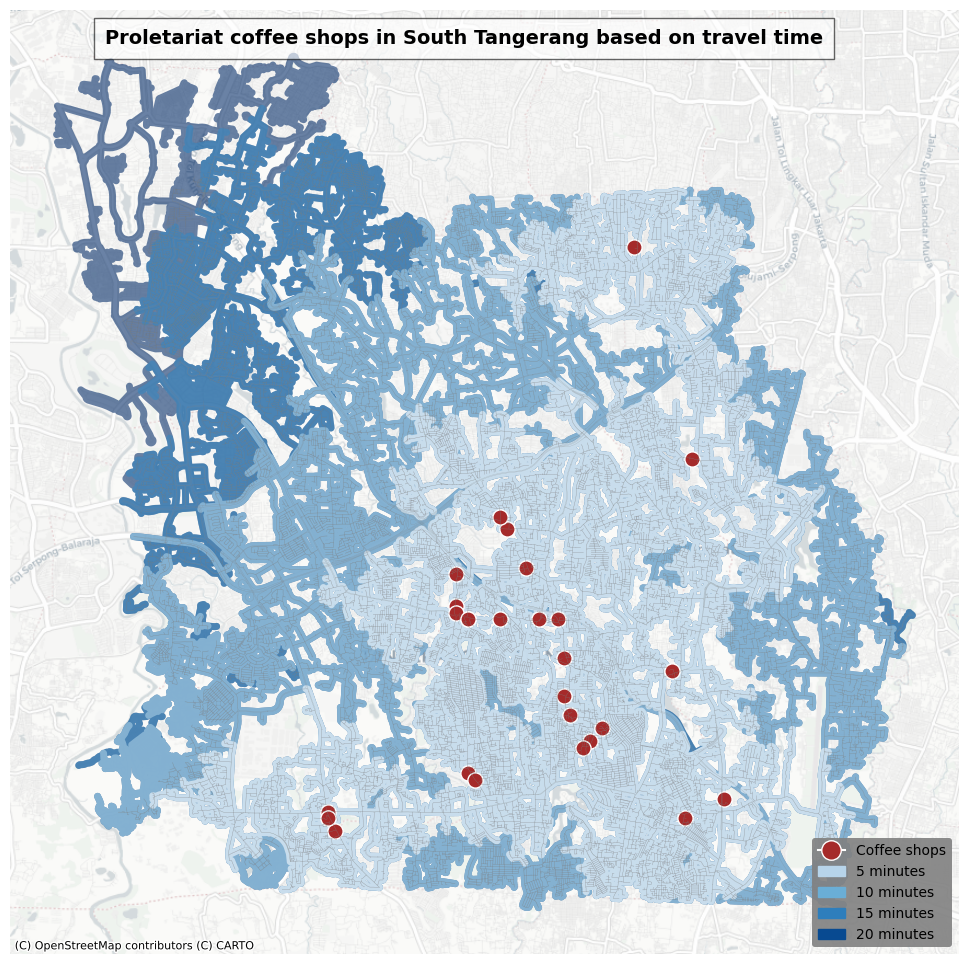

In [47]:
fig, ax = plt.subplots(figsize=(10, 10))

# Adding isochrone result
iso_plot = iso_plot.sort_values("travel_time", ascending=False)
iso_plot.plot(
    ax=ax,
    column='travel_time',
    cmap='Blues',
    alpha=0.6,
    edgecolor='none',
    legend=False
)

# Adding street network
edges_plot.plot(ax=ax, linewidth=0.2, color='grey', alpha=0.5)

# Adding coffee shops
warkop_gdf.plot(
    ax=ax,
    color='brown',
    markersize=120,
    marker='o',
    edgecolor='white'
)

# Adding basemap
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

# Adding title
ax.text(
    0.1, 0.98,
    "Proletariat coffee shops in South Tangerang based on travel time", 
    transform=ax.transAxes,
    fontsize=14,
    fontweight='bold',
    color='black',
    ha='left',
    va='top',
    zorder=1000,
    bbox=dict(
        facecolor='white',
        alpha=0.6,
        pad=8
    )
)


# Adding legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='brown',
           markeredgecolor='white',
           markersize=14,
           label='Coffee shops'),

    patches.Patch(color=plt.cm.Blues(0.3), label='5 minutes'),
    patches.Patch(color=plt.cm.Blues(0.5), label='10 minutes'),
    patches.Patch(color=plt.cm.Blues(0.7), label='15 minutes'),
    patches.Patch(color=plt.cm.Blues(0.9), label='20 minutes')
]

legend = ax.legend(
    handles=legend_elements,
    loc="lower right",
    frameon=True,
    facecolor="grey",
    framealpha=0.9,
    edgecolor="none"
)

# Erasing edgeline and ticks
ax.set_xticks([])
ax.set_yticks([])
ax.set_frame_on(False)

# Final result
plt.tight_layout()
plt.savefig("warkop_isochrone.png", dpi=300, bbox_inches='tight')
plt.show()